# CNN Model Training and Evaluation

This notebook trains a baseline CNN using the same generators from `preprocessing.py`.


Skipping data/raw\cardboard: Already has 300 images.
Skipping data/raw\glass: Already has 300 images.
Skipping data/raw\metal: Already has 300 images.
Skipping data/raw\plastic: Already has 300 images.
Found 960 images belonging to 4 classes.
Found 240 images belonging to 4 classes.

Training images: 960
Validation images: 240


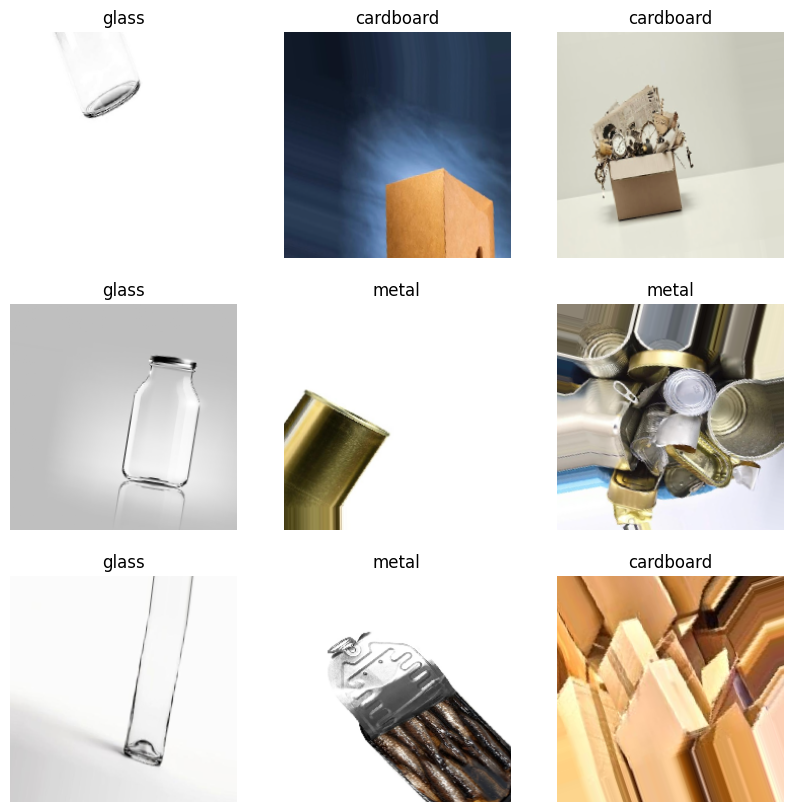

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 457,156 (1.74 MB)

 Trainable params: 456,196 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

In [1]:
import tensorflow as tf
from keras import layers, Model
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import preprocessing

NUM_CLASSES = 4
IMG_SIZE = (224, 224)

def build_cnn_model(num_classes):
    inputs = tf.keras.Input(shape=(224, 224, 3))

    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(256, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return Model(inputs, outputs)

cnn_model = build_cnn_model(NUM_CLASSES)
cnn_model.summary()


In [2]:
cnn_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True, monitor="val_accuracy"),
    ReduceLROnPlateau(factor=0.5, patience=4, monitor="val_loss", verbose=1),
    ModelCheckpoint("best_cnn_model.keras", save_best_only=True, monitor="val_accuracy")
]

history_cnn = cnn_model.fit(
    preprocessing.train_generator,
    epochs=50,
    validation_data=preprocessing.val_generator,
    callbacks=cnn_callbacks,
)


Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 51s 781ms/step - accuracy: 0.5354 - loss: 1.1139 - val_accuracy: 0.2625 - val_loss: 1.6911 - learning_rate: 1.0000e-04
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 30s 497ms/step - accuracy: 0.6302 - loss: 0.9357 - val_accuracy: 0.4625 - val_loss: 1.3354 - learning_rate: 1.0000e-04
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 29s 485ms/step - accuracy: 0.6542 - loss: 0.8565 - val_accuracy: 0.5208 - val_loss: 1.0866 - learning_rate: 1.0000e-04
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 30s 490ms/step - accuracy: 0.6760 - loss: 0.8167 - val_accuracy: 0.6208 - val_loss: 0.9525 - learning_rate: 1.0000e-04
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 31s 508ms/step - accuracy: 0.7417 - loss: 0.7142 - val_accuracy: 0.7125 - val_loss: 0.8203 - learning_rate: 1.0000e-04
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 40s 499ms/step - accuracy: 0.7479 - loss: 0.6844 - val_accuracy: 0.6750 - val_loss: 0.8424 - learning_rate: 1.0000e-04
Epoch 7/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 29s 489ms/step - acc

In [3]:
from keras.models import load_model

cnn_model = load_model("best_cnn_model.keras")
print(type(cnn_model))
print("CNN model loaded")

preprocessing.val_generator.reset()
loss_cnn, accuracy_cnn = cnn_model.evaluate(preprocessing.val_generator, verbose=1) # type: ignore
print(f"\nCNN Final Val Accuracy : {accuracy_cnn*100:.2f}%")
print(f"CNN Final Val Loss     : {loss_cnn:.4f}")


<class 'keras.src.models.functional.Functional'>
CNN model loaded
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.8542 - loss: 0.5622

CNN Final Val Accuracy : 85.42%
CNN Final Val Loss     : 0.5622


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step

=== CNN Classification Report ===
              precision    recall  f1-score   support

   cardboard       0.96      0.90      0.93        60
       glass       0.87      0.88      0.88        60
       metal       0.73      0.87      0.79        60
     plastic       0.88      0.77      0.82        60

    accuracy                           0.85       240
   macro avg       0.86      0.85      0.86       240
weighted avg       0.86      0.85      0.86       240



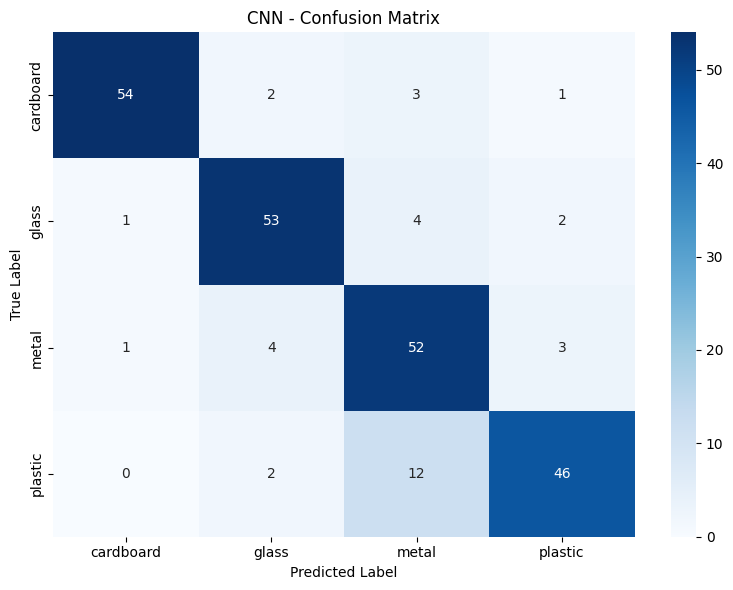

In [4]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

preprocessing.val_generator.reset()
y_pred_probs_cnn = cnn_model.predict(preprocessing.val_generator, verbose=1)
y_pred_cnn = np.argmax(y_pred_probs_cnn, axis=1)
y_true_cnn = preprocessing.val_generator.classes
CLASS_NAMES = list(preprocessing.val_generator.class_indices.keys())

print("\n=== CNN Classification Report ===")
print(classification_report(y_true_cnn, y_pred_cnn, target_names=CLASS_NAMES))

cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cnn, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("CNN - Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("cnn_confusion_matrix.png", dpi=150)
plt.show()


## Inference (CNN only)

Run after training (or ensure `best_cnn_model.keras` exists). Uses the same image preprocessing as `preprocessing.py` (`preprocess_input`), so it matches how the CNN was trained on the generators.


In [ ]:
from keras.models import load_model
from keras.applications.efficientnet import preprocess_input

cnn_infer = load_model("best_cnn_model.keras")

CLASS_NAMES_CNN = [
    name for name, _ in sorted(
        preprocessing.val_generator.class_indices.items(),
        key=lambda kv: kv[1],
    )
]

BIN_ROUTING_CNN = {
    'cardboard': ('Blue Bin', 'Paper & Cardboard Recycling'),
    'glass':     ('Green Bin', 'Glass Recycling'),
    'metal':     ('Yellow Bin', 'Metal & Cans Recycling'),
    'plastic':   ('Red Bin', 'Plastic Recycling'),
}

def predict_cnn(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
    arr = preprocess_input(tf.keras.utils.img_to_array(img))
    batch = np.expand_dims(arr, axis=0)

    probs = cnn_infer.predict(batch, verbose=0)[0]
    idx = int(np.argmax(probs))
    predicted_class = CLASS_NAMES_CNN[idx]
    confidence = float(probs[idx])
    bin_name, bin_desc = BIN_ROUTING_CNN[predicted_class]

    print(f"\nWaste Type  : {predicted_class.upper()}")
    print(f"Throw in    : {bin_name} - {bin_desc}")
    print(f"Confidence  : {confidence*100:.1f}%")
    for name, p in zip(CLASS_NAMES_CNN, probs):
        print(f"  {name:<12} {p*100:5.1f}%")

    plt.figure(figsize=(5, 5))
    plt.imshow(tf.keras.utils.load_img(img_path))
    plt.title(f"{predicted_class.upper()} - {bin_name}\n({confidence*100:.1f}%)")
    plt.axis("off")
    plt.show()

    return predicted_class, probs


In [ ]:
predict_cnn("data/raw/glass/aug_0_1040.jpg")


# 6- MULTIMODELING (CNN + LSTM)


## 6.1 Bin Routing Text + Tokenizer


In [5]:
CLASS_TEXT = {
    'cardboard': 'cardboard paper waste goes in the blue recycling bin',
    'glass':     'glass bottle jar waste goes in the green glass bin',
    'metal':     'metal can tin waste goes in the yellow metal bin',
    'plastic':   'plastic bottle container goes in the red plastic bin',
}

CLASS_NAMES = sorted(CLASS_TEXT.keys())
texts = [CLASS_TEXT[c] for c in CLASS_NAMES]

all_words = ' '.join(texts).split()
vocab = ['<PAD>'] + sorted(set(all_words))
word_to_idx = {w: i for i, w in enumerate(vocab)}
VOCAB_SIZE = len(vocab)
MAX_SEQ_LEN = max(len(t.split()) for t in texts)

def encode(text):
    tokens = [word_to_idx[w] for w in text.split()]
    return tokens + [0] * (MAX_SEQ_LEN - len(tokens))

text_padded = np.array([encode(t) for t in texts])
class_to_text = {i: text_padded[i] for i in range(len(CLASS_NAMES))}

print(f"Classes     : {CLASS_NAMES}")
print(f"Vocab size  : {VOCAB_SIZE}")
print(f"Seq length  : {MAX_SEQ_LEN}")
for i, name in enumerate(CLASS_NAMES):
    print(f"  [{i}] {name:<12}  {text_padded[i]}")


Classes     : ['cardboard', 'glass', 'metal', 'plastic']
Vocab size  : 21
Seq length  : 10
  [0] cardboard     [ 5 13 19  8 10 17  2 15  1  0]
  [1] glass         [ 7  3 11 19  8 10 17  9  7  1]
  [2] metal         [12  4 18 19  8 10 17 20 12  1]
  [3] plastic       [14  3  6  8 10 17 16 14  1  0]


## 6.2 Multimodal Generator


In [6]:
def make_multimodal_generator(image_gen, class_to_text):
    for images, labels in image_gen:
        class_indices = np.argmax(labels, axis=1)
        texts_batch = np.array([class_to_text[idx] for idx in class_indices])
        yield (images, texts_batch), labels


## 6.3 Build Multimodal Model


In [7]:
from keras.models import load_model

trained_cnn_model = load_model("best_cnn_model.keras")
trained_cnn_model.trainable = False

feature_extractor = Model(
    inputs=trained_cnn_model.input,
    outputs=trained_cnn_model.layers[-2].output,
    name="cnn_features"
)
feature_extractor.trainable = False

image_input = tf.keras.Input(shape=(224, 224, 3), name="image_input")
img_features = feature_extractor(image_input)

text_input = tf.keras.Input(shape=(MAX_SEQ_LEN,), name="text_input")
x = layers.Embedding(VOCAB_SIZE, 64)(text_input)
x = layers.LSTM(128)(x)
x = layers.Dense(128, activation='relu')(x)
text_features = layers.Dropout(0.3)(x)

merged = layers.Concatenate(name="fusion")([img_features, text_features])
merged = layers.Dense(256, activation='relu')(merged)
merged = layers.Dropout(0.4)(merged)
merged = layers.Dense(128, activation='relu')(merged)
merged = layers.Dropout(0.3)(merged)
output = layers.Dense(4, activation='softmax', name="output")(merged)

multimodal_model = Model(
    inputs=[image_input, text_input],
    outputs=output,
    name="multimodal_waste_classifier_cnn"
)

multimodal_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

multimodal_model.summary()


Model: "multimodal_waste_classifier_cnn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 10, 64)    │      1,344 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 128)       │     98,816 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     16,512 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_features        │ (None, 256)       │    456,128 │ image_input[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion              │ (None, 384)       │          0 │ cnn_features[0][… │
│ (Concatenate)       │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │     98,560 │ fusion[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     32,896 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 4)         │        516 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 704,772 (2.69 MB)

 Trainable params: 248,644 (971.27 KB)

 Non-trainable params: 456,128 (1.74 MB)

## 6.4 Train


In [8]:
preprocessing.train_generator.reset()
preprocessing.val_generator.reset()

train_mm = make_multimodal_generator(preprocessing.train_generator, class_to_text)
val_mm = make_multimodal_generator(preprocessing.val_generator, class_to_text)

callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True, monitor="val_accuracy"),
    ModelCheckpoint("best_multimodal_cnn.keras", save_best_only=True, monitor="val_accuracy")
]

history_mm = multimodal_model.fit(
    train_mm,
    steps_per_epoch=len(preprocessing.train_generator),
    epochs=30,
    validation_data=val_mm,
    validation_steps=len(preprocessing.val_generator),
    callbacks=callbacks
)


Epoch 1/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 171ms/step - accuracy: 0.2896 - loss: 1.4797 - val_accuracy: 0.6917 - val_loss: 1.1204
Epoch 2/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 164ms/step - accuracy: 0.5354 - loss: 1.1185 - val_accuracy: 0.7708 - val_loss: 0.8573
Epoch 3/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 156ms/step - accuracy: 0.7094 - loss: 0.8637 - val_accuracy: 0.9417 - val_loss: 0.4918
Epoch 4/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 150ms/step - accuracy: 0.9594 - loss: 0.2330 - val_accuracy: 0.9917 - val_loss: 0.0910
Epoch 5/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 163ms/step - accuracy: 1.0000 - loss: 0.0178 - val_accuracy: 0.9958 - val_loss: 0.0731
Epoch 6/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 159ms/step - accuracy: 0.9990 - loss: 0.0084 - val_accuracy: 0.9958 - val_loss: 0.0618
Epoch 7/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 155ms/step - accuracy: 1.0000 - loss: 0.0032 - val_accuracy: 0.9958 - val_loss: 0.0581
Epoch 8/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 147ms/step - accuracy: 1.0000 - loss: 0.0028 - val_accuracy:

## 6.5 Confusion Matrix


              precision    recall  f1-score   support

   cardboard       0.98      1.00      0.99        60
       glass       1.00      1.00      1.00        60
       metal       1.00      0.98      0.99        60
     plastic       1.00      1.00      1.00        60

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



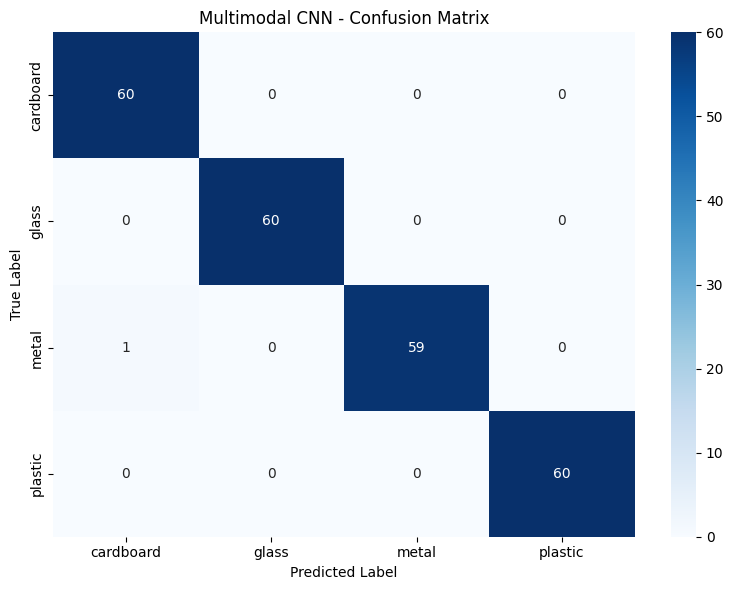

In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

preprocessing.val_generator.reset()
val_mm_pred = make_multimodal_generator(preprocessing.val_generator, class_to_text)

y_pred_probs, y_true = [], []
for (imgs, txts), labels in val_mm_pred:
    preds = multimodal_model.predict([imgs, txts], verbose=0)
    y_pred_probs.extend(preds)
    y_true.extend(np.argmax(labels, axis=1))
    if len(y_true) >= preprocessing.val_generator.samples:
        break

y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.array(y_true)

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Multimodal CNN - Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("confusion_matrix_multimodal_cnn.png", dpi=150)
plt.show()


## 6.6 Inference


In [10]:
import os
from keras.applications.efficientnet import preprocess_input

BIN_ROUTING = {
    'cardboard': ('Blue Bin', 'Paper & Cardboard Recycling'),
    'glass':     ('Green Bin', 'Glass Recycling'),
    'metal':     ('Yellow Bin', 'Metal & Cans Recycling'),
    'plastic':   ('Red Bin', 'Plastic Recycling'),
}

def predict_multimodal(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
    arr = preprocess_input(tf.keras.utils.img_to_array(img))
    img_batch = np.expand_dims(arr, axis=0)

    all_probs = np.zeros(4)
    for class_idx in range(4):
        text_batch = np.expand_dims(class_to_text[class_idx], axis=0)
        probs = multimodal_model.predict([img_batch, text_batch], verbose=0)[0]
        all_probs += probs
    all_probs /= 4

    predicted_idx = np.argmax(all_probs)
    predicted_class = CLASS_NAMES[predicted_idx]
    confidence = all_probs[predicted_idx]
    bin_name, bin_desc = BIN_ROUTING[predicted_class]

    print(f"\nWaste Type  : {predicted_class.upper()}")
    print(f"Throw in    : {bin_name} - {bin_desc}")
    print(f"Confidence  : {confidence*100:.1f}%")

    plt.figure(figsize=(5, 5))
    plt.imshow(tf.keras.utils.load_img(img_path))
    plt.title(f"{predicted_class.upper()} - {bin_name}\n({confidence*100:.1f}%)")
    plt.axis("off")
    plt.show()

for cls in CLASS_NAMES:
    folder = f"data/raw/{cls}"
    first = os.listdir(folder)[0]
    print(f"{cls:<12}  data/raw/{cls}/{first}")


cardboard     data/raw/cardboard/aug_0_1003.jpg
glass         data/raw/glass/aug_0_1040.jpg
metal         data/raw/metal/aug_0_1004.jpg
plastic       data/raw/plastic/5NGmdEdHLUpsgy9pi0saGctJdCv1wSVx_Rw20x4zysjKD5BzoQR14-W-IzfWdM57Az2ym5xNuMLvfMiYOWi5q8OMjcZN1Qp-K9cHEzqqEqgw4HeSIw6Lvnu5TVO76Pih1wGT0bpnvanctxaFZQfKdlSBkkGMdXE9C_RaSb5QMxRTJCaR5r6LHApPgPO54XVU.jpeg



Waste Type  : GLASS
Throw in    : Green Bin - Glass Recycling
Confidence  : 25.1%


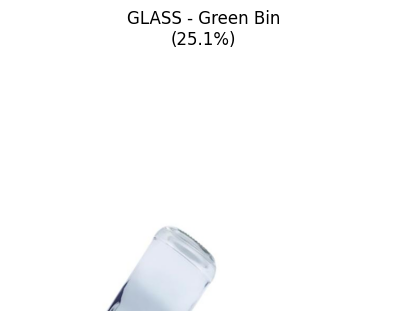

In [11]:
predict_multimodal("data/raw/glass/aug_0_1040.jpg")
